In [15]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import OptimalBattery.estimate as es



# define atlas and dirs

In [16]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [17]:
model_dir = f'{cerebellum_dir}/ProbabilisticParcellationModel/Models/Models_03/'
model_name='NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir+model_name, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
#exclude rest because it will be removed from the data in the centering step
VL_mdtb_1 = VL_mdtb_1[:,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()

In [18]:
lut_file_dir = f'{cerebellum_dir}/ProbabilisticParcellationModel/Atlases/NettekovenSym32.lut'
lut = pd.read_csv(lut_file_dir, sep=' ', header=None)
# ge the parcel names from the 4th column
parcel_names = lut.iloc[:,4].values
parcel_names = parcel_names[1:]
len(parcel_names)

32

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [19]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]

data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0
data_mdtb_s2_all = data_mdtb_s2_all[:,:,:]



# parcellation

In [ ]:
# roi (prefrontal cortex)
ROI_cortex = np.arange(0, 33)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'

parcelation = atlas.read_data(model_name)
ROI_mask = np.isin(parcelation, ROI_cortex).astype(int)


In [34]:
Vs_train ,parcel_list= es.get_training_Vs(data_mdtb_s1_all, parcelation, ROI_mask, n_parcels=32)
cond_names_1 = info_mdtb_1_all['cond_name']

In [35]:
Vs_test = es.get_testing_Vs(data_mdtb_s2_all, parcelation, ROI_mask, parcel_list)
cond_names_2 = info_mdtb_2_all['cond_name']

# compare the Vs of train and test under Nettekoven 32 and under computing mean within nettekoven 32 parcel

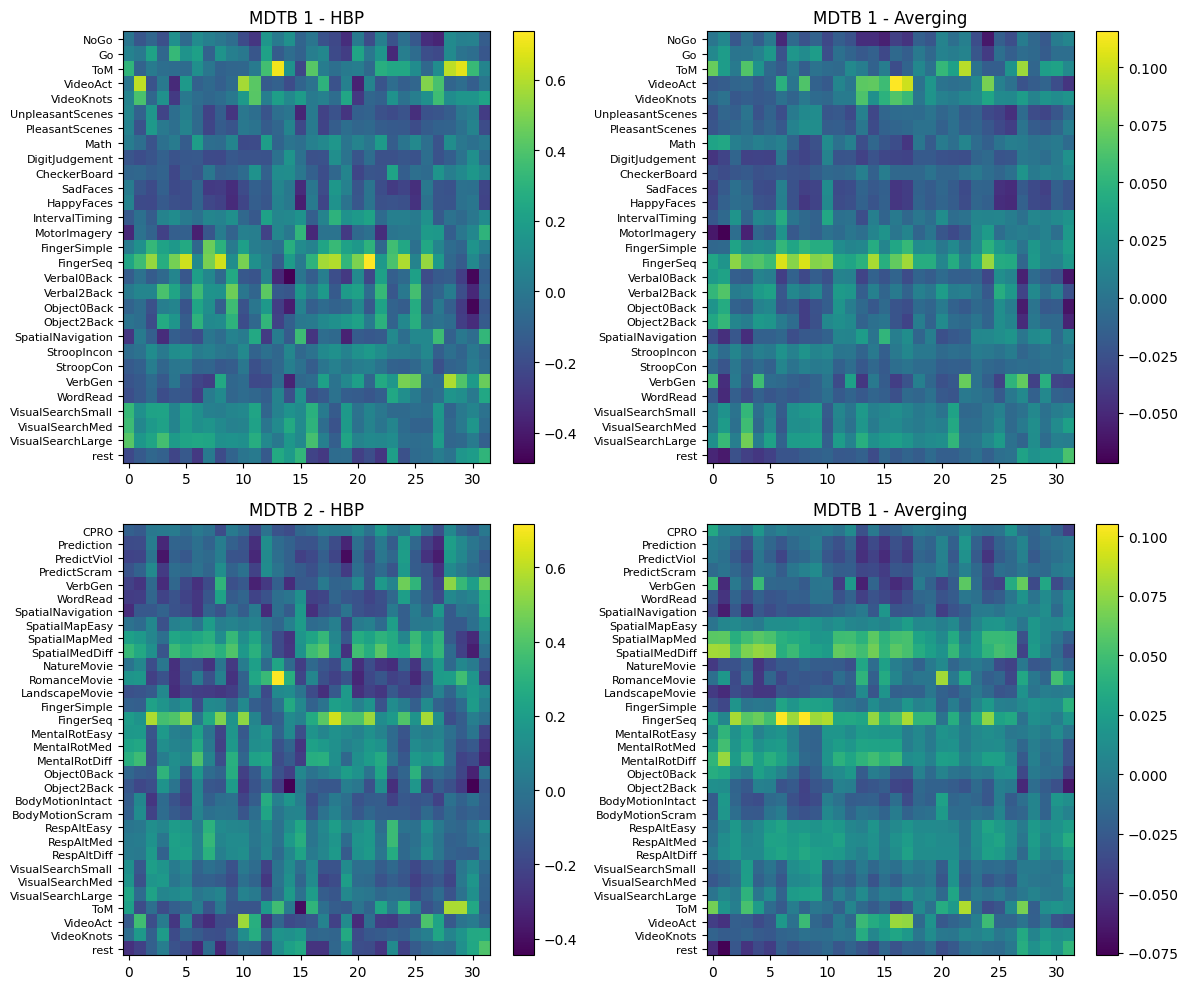

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_data = [
    (VL_mdtb_1, Vs_train, cond_names_1, "MDTB 1 - HBP", "MDTB 1 - Averging"),
    (VL_mdtb_2, Vs_test, cond_names_2, "MDTB 2 - HBP", "MDTB 1 - Averging")
]

for i, (VL, Vs, cond_names, title_VL, title_Vs) in enumerate(plot_data):
    im1 = axes[i, 0].imshow(VL, aspect='auto', cmap='viridis')
    axes[i, 0].set_title(title_VL)
    axes[i, 0].set_yticks(range(len(cond_names)))
    axes[i, 0].set_yticklabels(cond_names, fontsize=8)
    fig.colorbar(im1, ax=axes[i, 0])

    im2 = axes[i, 1].imshow(Vs, aspect='auto', cmap='viridis')
    axes[i, 1].set_title(title_Vs)
    axes[i, 1].set_yticks(range(len(cond_names)))
    axes[i, 1].set_yticklabels(cond_names, fontsize=8)
    fig.colorbar(im2, ax=axes[i, 1])

plt.tight_layout()
plt.show()
